# 📈 Exploring Multi-Currency Hourly Forex Data with Neural Networks

This notebook focuses on preparing and exploring a 5-year dataset of hourly foreign exchange (forex) quotes for three major currency pairs: **EUR/USD**, **GBP/USD**, and **USD/JPY**. These represent some of the most actively traded pairs in global currency markets, and analyzing them together offers insights into currency correlations, trends, and cross-market behavior.

## 🔍 Objective

The primary goal of this notebook is to explore the capacity of neural networks to predict the price of a single asset using different sources of information.




In [1]:
import pandas as pd

# Paths to your files
file1 = 'EURUSD_H1_202001020300_202507011900.csv'
file2 = 'GBPUSD_H1_202001020300_202507011900.csv'
file3 = 'USDJPY_H1_202001020300_202507011900.csv'

# Read and keep only DATE, TIME, CLOSE
df1 = pd.read_csv(file1, sep='\t', usecols=['<DATE>', '<TIME>', '<CLOSE>'])
df2 = pd.read_csv(file2, sep='\t', usecols=['<DATE>', '<TIME>', '<CLOSE>'])
df3 = pd.read_csv(file3, sep='\t', usecols=['<DATE>', '<TIME>', '<CLOSE>'])

# Rename CLOSE columns to distinguish them
df1.rename(columns={'<CLOSE>': 'EURUSD'}, inplace=True)
df2.rename(columns={'<CLOSE>': 'GBPUSD'}, inplace=True)
df3.rename(columns={'<CLOSE>': 'USDJPY'}, inplace=True)

# Merge on DATE and TIME
merged = df1.merge(df2, on=['<DATE>', '<TIME>']).merge(df3, on=['<DATE>', '<TIME>'])

# Create DATETIME column and convert to pandas datetime
merged['DATETIME'] = pd.to_datetime(merged['<DATE>'] + ' ' + merged['<TIME>'])

# Sort by DATETIME
merged.sort_values('DATETIME', inplace=True)
merged.drop(columns=['<DATE>', '<TIME>'], inplace=True)

# Final result
print(merged.head())
print(merged.tail())


    EURUSD   GBPUSD   USDJPY            DATETIME
0  1.12209  1.32557  108.670 2020-01-02 03:00:00
1  1.12221  1.32481  108.674 2020-01-02 04:00:00
2  1.12132  1.32091  108.703 2020-01-02 05:00:00
3  1.12011  1.32069  108.738 2020-01-02 06:00:00
4  1.12043  1.32135  108.738 2020-01-02 07:00:00
        EURUSD   GBPUSD   USDJPY            DATETIME
34203  1.18033  1.37409  143.068 2025-07-01 15:00:00
34204  1.18020  1.37334  143.060 2025-07-01 16:00:00
34205  1.17796  1.37176  143.437 2025-07-01 17:00:00
34206  1.17756  1.37239  143.575 2025-07-01 18:00:00
34207  1.17651  1.37241  143.690 2025-07-01 19:00:00


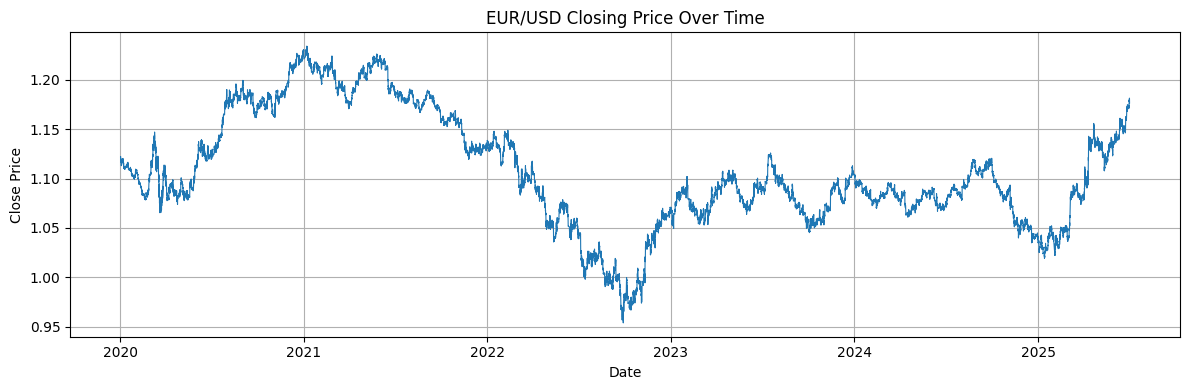

In [2]:
import matplotlib.pyplot as plt

# Plot EUR/USD close price over time
plt.figure(figsize=(12, 4))
plt.plot(merged['DATETIME'], merged['EURUSD'], linewidth=0.8)
plt.title('EUR/USD Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
# Define the neural network using Jax (https://docs.jax.dev/en/latest/index.html)
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from flax import linen as nn
from flax.training import train_state
from sklearn.model_selection import train_test_split
import numpy as np

# --- Define the MLP ---
class MLP(nn.Module):
    N1: int
    N2: int

    @nn.compact
    def __call__(self, x):
        x = nn.relu(nn.Dense(self.N1)(x))
        x = nn.relu(nn.Dense(self.N2)(x))
        x = nn.Dense(1)(x)  # Scalar output
        return x

In [4]:
# --- Prepare data from merged ---
def create_dataset(series, Nprevious, Nahead):
    X, y = [], []
    for i in range(len(series) - Nprevious - Nahead):
        X.append(series[i:i+Nprevious])
        y.append(series[i + Nprevious + Nahead - 1])  # 1-based offset
    return np.array(X), np.array(y).reshape(-1, 1)

# --- Settings ---
Nprevious = 120
Nahead = 48
N1, N2 = 64, 32
batch_size = 128
epochs = 50
learning_rate = 1e-4

# Use EURUSD close prices (already sorted by datetime)
series = merged['EURUSD'].to_numpy()
X, y = create_dataset(series, Nprevious, Nahead)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    shuffle=False)

# Convert to jax arrays
X_train, y_train = jnp.array(X_train), jnp.array(y_train)
X_test, y_test = jnp.array(X_test), jnp.array(y_test)

In [5]:
# --- Create training state ---
def create_train_state(rng, model, learning_rate):
    params = model.init(rng, X_train[:1])
    tx = optax.adam(learning_rate)
    return train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

# --- Define loss and update functions ---
from functools import partial

@partial(jax.jit, static_argnums=(1,))
def loss_fn(params, apply_fn, x, y):
    pred = apply_fn(params, x)
    return jnp.mean(jnp.abs(pred - y))  # MAE

def evaluate_mae(state, X, y):
    preds = state.apply_fn(state.params, X)
    return jnp.mean(jnp.abs(preds - y)).item()

@partial(jax.jit, static_argnums=(1,))
def train_step(state, apply_fn, x, y):
    grad_fn = jax.value_and_grad(loss_fn)
    loss, grads = grad_fn(state.params, apply_fn, x, y)
    state = state.apply_gradients(grads=grads)
    return state, loss

In [10]:
def trainModel(X_train, y_train, X_test, y_test, epochs):
  model = MLP(N1=N1, N2=N2)
  rng = jax.random.PRNGKey(0)
  state = create_train_state(rng, model, learning_rate)

  train_losses = []
  test_losses = []

  for epoch in range(epochs):
      # Shuffle training data
      perm = jax.random.permutation(rng, len(X_train))
      X_train, y_train = X_train[perm], y_train[perm]

      # Training loop
      epoch_loss = 0
      for i in range(0, len(X_train), batch_size):
          xb = X_train[i:i+batch_size]
          yb = y_train[i:i+batch_size]
          state, loss = train_step(state, state.apply_fn, xb, yb)
          epoch_loss += float(loss) * len(xb)

      epoch_loss /= len(X_train)
      train_losses.append(epoch_loss)

      # Evaluate on test set
      test_loss = evaluate_mae(state, X_test, y_test)
      test_losses.append(test_loss)

      print(f"Epoch {epoch+1}/{epochs}, Train MAE: {epoch_loss:.6f}, Test MAE: {test_loss:.6f}")
  return state, train_losses, test_losses
state, train_losses, test_losses = trainModel(X_train, y_train, X_test, y_test, epochs)

Epoch 1/50, Train MAE: 0.022465, Test MAE: 0.006457
Epoch 2/50, Train MAE: 0.006934, Test MAE: 0.006439
Epoch 3/50, Train MAE: 0.006998, Test MAE: 0.006424
Epoch 4/50, Train MAE: 0.007119, Test MAE: 0.006468
Epoch 5/50, Train MAE: 0.007242, Test MAE: 0.006634
Epoch 6/50, Train MAE: 0.006925, Test MAE: 0.006700
Epoch 7/50, Train MAE: 0.007020, Test MAE: 0.006423
Epoch 8/50, Train MAE: 0.007013, Test MAE: 0.006934
Epoch 9/50, Train MAE: 0.007114, Test MAE: 0.006747
Epoch 10/50, Train MAE: 0.007210, Test MAE: 0.006336
Epoch 11/50, Train MAE: 0.007161, Test MAE: 0.006470
Epoch 12/50, Train MAE: 0.007136, Test MAE: 0.006722
Epoch 13/50, Train MAE: 0.006831, Test MAE: 0.006327
Epoch 14/50, Train MAE: 0.007181, Test MAE: 0.006423
Epoch 15/50, Train MAE: 0.006823, Test MAE: 0.006764
Epoch 16/50, Train MAE: 0.006959, Test MAE: 0.007590
Epoch 17/50, Train MAE: 0.006971, Test MAE: 0.008291
Epoch 18/50, Train MAE: 0.007009, Test MAE: 0.006288
Epoch 19/50, Train MAE: 0.007140, Test MAE: 0.006402
Ep

In [11]:
# --- Compute Naive Baseline MAE on Test Set ---
def compute_naive_mae(series, Nprevious, Nahead, test_start_index):
    """
    Naive forecast: predict close[n+Nahead] using close[n+Nprevious-1]
    """
    y_true = []
    y_pred = []

    max_i = len(series) -Nprevious-Nahead

    for i in range(test_start_index, max_i):
        y_true.append(series[i + Nprevious+Nahead])
        y_pred.append(series[i + Nprevious])  # Last value in the input window

    y_true = jnp.array(y_true)
    y_pred = jnp.array(y_pred)
    return jnp.mean(jnp.abs(y_pred - y_true)).item()

# Use original unshuffled series to find test start index
test_start_index = 1

# Calculate baseline MAE
naive_mae = compute_naive_mae(series, Nprevious, Nahead, test_start_index)
print(f"Naive baseline MAE (predicting future from current): {naive_mae:.6f}")

Naive baseline MAE (predicting future from current): 0.005629


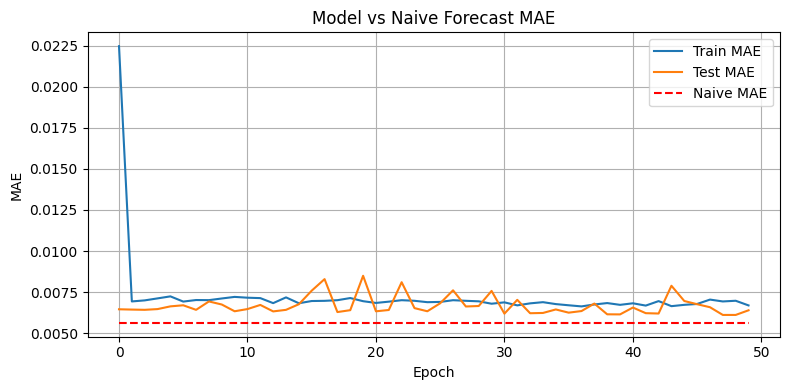

In [12]:
# --- Plot loss ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MAE')
plt.plot(test_losses, label='Test MAE')
plt.hlines(naive_mae, xmin=0, xmax=epochs-1, color='r', linestyles='dashed', label='Naive MAE')
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Model vs Naive Forecast MAE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

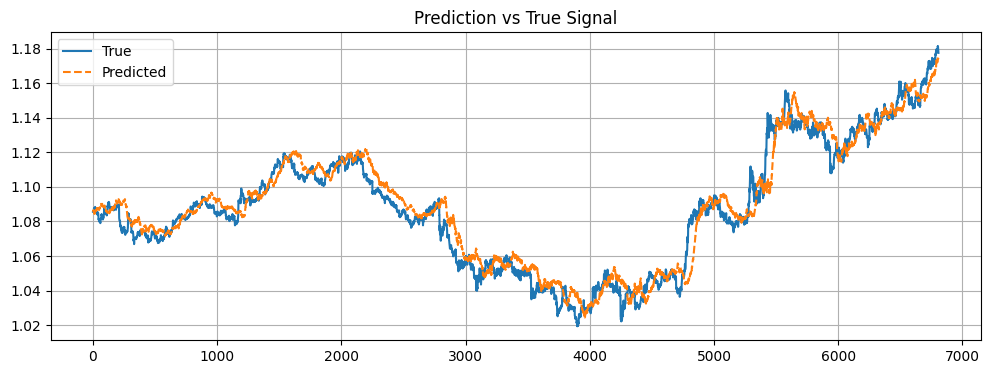

In [13]:
y_pred = state.apply_fn(state.params, X_test)

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(y_test)), y_test, label='True')
plt.plot(np.arange(len(y_test)), y_pred, label='Predicted', linestyle='--')
plt.title('Prediction vs True Signal')
plt.legend()
plt.grid(True)
plt.show()

## More predictors
Let's include now GBPUSD and USDJPY as predictors

In [14]:
def create_dataset_multivariate(data: np.ndarray, Nprevious: int, Nahead: int):
    """
    data: 2D array of shape (T, 3), where each column is one currency
    Returns X of shape (N_samples, Nprevious * 3) and y of shape (N_samples, 1)
    """
    X, y = [], []
    for i in range(len(data) - Nprevious - Nahead):
        x_window = data[i : i + Nprevious]  # shape (Nprevious, 3)
        x_flat = x_window.flatten()         # flatten to (Nprevious * 3,)
        X.append(x_flat)
        y.append(data[i + Nprevious + Nahead - 1, 0])  # EURUSD is column 0
    return np.array(X), np.array(y).reshape(-1, 1)

data = merged[['EURUSD', 'GBPUSD', 'USDJPY']].to_numpy()
data[:,2]/=150 # Because USDJPY is about 150
X, y = create_dataset_multivariate(data, Nprevious, Nahead)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    shuffle=False)

# Convert to jax arrays
X_train, y_train = jnp.array(X_train), jnp.array(y_train)
X_test, y_test = jnp.array(X_test), jnp.array(y_test)
state, train_losses, test_losses = trainModel(X_train, y_train, X_test, y_test, epochs)

Epoch 1/50, Train MAE: 0.057389, Test MAE: 0.012311
Epoch 2/50, Train MAE: 0.012669, Test MAE: 0.016978
Epoch 3/50, Train MAE: 0.011588, Test MAE: 0.011016
Epoch 4/50, Train MAE: 0.010724, Test MAE: 0.009288
Epoch 5/50, Train MAE: 0.010281, Test MAE: 0.009890
Epoch 6/50, Train MAE: 0.010357, Test MAE: 0.008793
Epoch 7/50, Train MAE: 0.009218, Test MAE: 0.008440
Epoch 8/50, Train MAE: 0.009735, Test MAE: 0.010662
Epoch 9/50, Train MAE: 0.008924, Test MAE: 0.008249
Epoch 10/50, Train MAE: 0.009213, Test MAE: 0.008975
Epoch 11/50, Train MAE: 0.009254, Test MAE: 0.008183
Epoch 12/50, Train MAE: 0.009521, Test MAE: 0.007914
Epoch 13/50, Train MAE: 0.009664, Test MAE: 0.013799
Epoch 14/50, Train MAE: 0.009074, Test MAE: 0.008293
Epoch 15/50, Train MAE: 0.009297, Test MAE: 0.011978
Epoch 16/50, Train MAE: 0.008355, Test MAE: 0.009592
Epoch 17/50, Train MAE: 0.010024, Test MAE: 0.009225
Epoch 18/50, Train MAE: 0.008949, Test MAE: 0.011252
Epoch 19/50, Train MAE: 0.008896, Test MAE: 0.007467
Ep

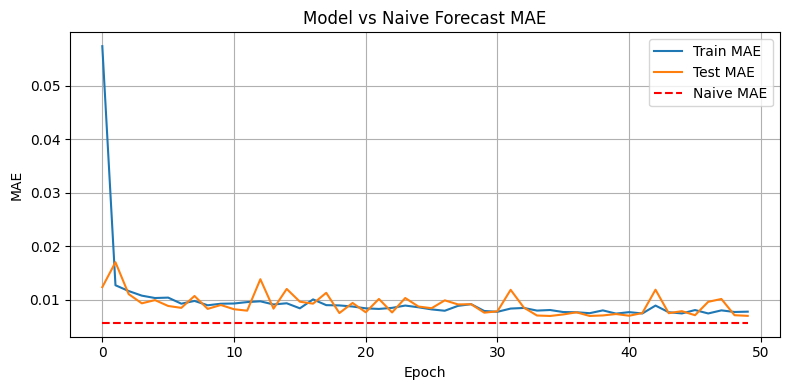

In [15]:
# --- Plot loss ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MAE')
plt.plot(test_losses, label='Test MAE')
plt.hlines(naive_mae, xmin=0, xmax=epochs-1, color='r', linestyles='dashed', label='Naive MAE')
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Model vs Naive Forecast MAE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

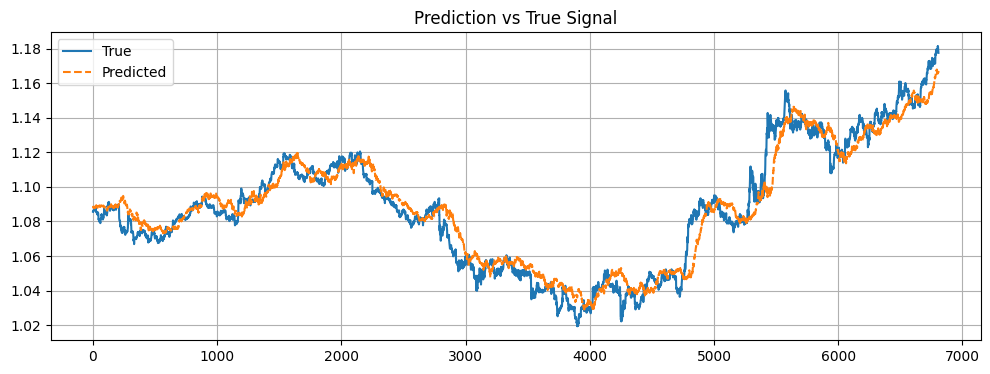

In [16]:
y_pred = state.apply_fn(state.params, X_test)

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(y_test)), y_test, label='True')
plt.plot(np.arange(len(y_test)), y_pred, label='Predicted', linestyle='--')
plt.title('Prediction vs True Signal')
plt.legend()
plt.grid(True)
plt.show()

## Deterministic signal
Is it that the NN cannot learn beyond a point?

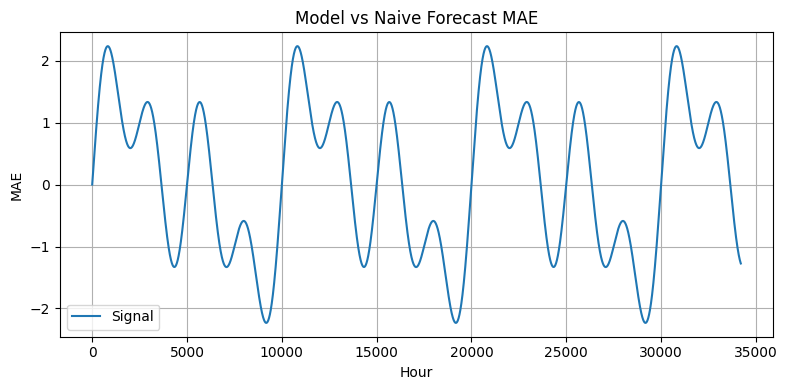

In [17]:
# Signal parameters
length = len(merged)

n = np.arange(length)
signal = (
    np.sin(2 * np.pi * n / 10000) +
    np.sin(2 * np.pi * n / 5000) +
    np.sin(2 * np.pi * n / 2500)
)
plt.figure(figsize=(8, 4))
plt.plot(signal, label='Signal')
plt.xlabel("Hour")
plt.ylabel("MAE")
plt.title("Model vs Naive Forecast MAE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
X, y = create_dataset(signal, Nprevious, Nahead)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    shuffle=False)

# Convert to jax arrays
X_train, y_train = jnp.array(X_train), jnp.array(y_train)
X_test, y_test = jnp.array(X_test), jnp.array(y_test)
state, train_losses, test_losses = trainModel(X_train, y_train, X_test, y_test, epochs)

Epoch 1/50, Train MAE: 0.214354, Test MAE: 0.060422
Epoch 2/50, Train MAE: 0.028328, Test MAE: 0.020820
Epoch 3/50, Train MAE: 0.014588, Test MAE: 0.014787
Epoch 4/50, Train MAE: 0.013906, Test MAE: 0.012395
Epoch 5/50, Train MAE: 0.013095, Test MAE: 0.014423
Epoch 6/50, Train MAE: 0.013462, Test MAE: 0.015086
Epoch 7/50, Train MAE: 0.012001, Test MAE: 0.013287
Epoch 8/50, Train MAE: 0.011987, Test MAE: 0.011395
Epoch 9/50, Train MAE: 0.012369, Test MAE: 0.009155
Epoch 10/50, Train MAE: 0.011789, Test MAE: 0.011488
Epoch 11/50, Train MAE: 0.011831, Test MAE: 0.016312
Epoch 12/50, Train MAE: 0.011792, Test MAE: 0.008604
Epoch 13/50, Train MAE: 0.010955, Test MAE: 0.009938
Epoch 14/50, Train MAE: 0.011715, Test MAE: 0.008566
Epoch 15/50, Train MAE: 0.010514, Test MAE: 0.011226
Epoch 16/50, Train MAE: 0.011522, Test MAE: 0.010030
Epoch 17/50, Train MAE: 0.010618, Test MAE: 0.012791
Epoch 18/50, Train MAE: 0.010766, Test MAE: 0.009623
Epoch 19/50, Train MAE: 0.010571, Test MAE: 0.012579
Ep

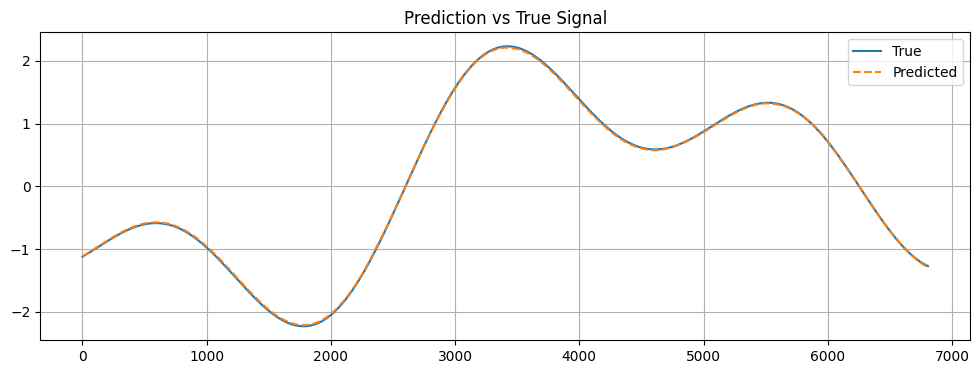

In [19]:
y_pred = state.apply_fn(state.params, X_test)

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(y_test)), y_test, label='True')
plt.plot(np.arange(len(y_test)), y_pred, label='Predicted', linestyle='--')
plt.title('Prediction vs True Signal')
plt.legend()
plt.grid(True)
plt.show()